# **===========================================================================================================================================================** #
# **Unit 4 End Project - Deep Learning** #
# **===========================================================================================================================================================** #
**Assignment Option B**: Create a model that predicts whether or not a loan will be default using historical data.</br>
This is a **Binary Classification** problem where we are trying to predict two (2) possible outcomes.</br>
- **Target Label**: not.fully.paid (NotFullyPaid)</br>
- **Two classes**: 0 (Fully Paid) or 1 (Not Fully Paid)</br>

In [ ]:
# Standard library imports
import itertools

from pathlib import Path
from shutil import rmtree
from typing import Tuple, Optional

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

### **EDA Utility Functions** ###

In [87]:

data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

### **Plot Utility Functions** ###

In [88]:
def DisplayBarPlot(df_Target, x_axis, y_axis, 
                    x_axis_label=None,
                    y_axis_label='Count',
                    plot_title=None, 
                    colors=None):

    # Plot
    plt.figure(figsize=(12, 6))

    if colors:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette=colors,
                        legend=False)
    else:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette='Blues_d', 
                        legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis_label, fontweight='bold')
    plt.ylabel(y_axis_label, fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()
    print()

In [89]:
def DisplaySimpleBarPlot(df_Target, x_axis, y_axis, plot_title):
    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=x_axis, 
                     y=y_axis, 
                     data=df_Target, 
                     hue=x_axis, 
                     palette='Blues_d', 
                     legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, displayLabels=True):

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=x_axis, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    plt.tight_layout()
    plt.show()


In [90]:
def DisplayNumericFeatureCountPlots(df_target, feature_columns = None, target_label=None, plot_title=None):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['int']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot.remove(target_label)
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a countplot
    for i, col in enumerate(cols_to_plot):

        #plt.figure(figsize=fig_size)
        sns.countplot(x=col, 
                    data=df_target, 
                    order=sorted(df_target[col].unique()), 
                    ax=axes[i],
                    hue=col, 
                    palette='Blues_d', 
                    legend=False)

        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = f'Count Plots for Binary Numeric Features of {plot_title}'
    else:
        title = 'Count Plots for Binary Numeric Features'

    plt.suptitle(title, y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

### **Global TensorFlow training configuration**

In [91]:
# Remove and recreate logs directory to clear any old TensorBoard logs
log_dir = ('../logs')
rmtree(log_dir, ignore_errors=True)
Path(log_dir).mkdir(parents=True, exist_ok=True)

# Set verbosity for wherever it's accepted
verbose = 0

# Fix TensorFlow random state for reproducibility
tf.random.set_seed(315)

### **Initial Data Load** ###

In [92]:
# Loading Lending Club Dataset
df_LendingClub_Original = pd.read_csv('../data/Unit4EndProject/Lending_Club.csv')

# Make a copy of the dataframe to contain the modifications completed in this workbook
df_LendingClub = df_LendingClub_Original.copy(deep=True)


## **1. Initial Exploratory Data Analysis - EDA** ##

In [93]:
# print out the dataframes stats
print('LendingClub Modeling')
# PrintDataFrameStatistics(df_LendingClub)

LendingClub Modeling


### Features and Label

In [94]:
data_set_name = 'Lending Club'

original_label = 'not.fully.paid'
original_features = ['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 
                     'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']

# PrintDataFrameStatistics(df_LendingClub)

#### Changes for Readability ####
First thing I want to do is clean up the column names so they are human-readable-friendly.</br>
This will make them easier to read, remember, plot and work with.

**Dataset columns and definition:**
- **credit.policy** => **CreditPolicy** : 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
- **purpose** => **Purpose**: The purpose of the loan
    - (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
- **int.rate** => **InterestRate**: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11).</br>
Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
- **installment** => **Installment**: The monthly installments owed by the borrower if the loan is funded.
- **log.annual.inc** => **LogAnnualIncome**: The natural log of the self-reported annual income of the borrower.
- **dti** => **DebitToIncomeRatio**: The debt-to-income ratio of the borrower (the amount of debt divided by annual income).
- **fico** => **FicoScore**: The FICO credit score of the borrower.
- **days.with.cr.line** => **DaysWithCreditLine**: The number of days the borrower has had a credit line.
- **revol.bal** => **RevolvingBalance**: The borrower's revolving balance (the amount unpaid at the end of the credit card billing cycle).
- **revol.util** => **RevolvingUtilRate**: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
- **inq.last.6mths** => **NumberCreditInquiries**: The borrower's number of inquiries by creditors in the last 6 months.
- **delinq.2yrs** => **Delinquencies** : The number of times the borrower has been 30+ days past due on a payment in the past 2 years.
- **pub.rec** => **NegativePublicRecords**: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).
- **not.fully.paid** => **NotFullyPaid**: TARGET - imbalanced data

***********************************
Description Stats
***********************************

                  Feature   count unique                 top  freq  \
0            CreditPolicy  9578.0    NaN                 NaN   NaN   
1                 Purpose    9578      7  debt_consolidation  3957   
2            InterestRate  9578.0    NaN                 NaN   NaN   
3      MonthlyInstallment  9578.0    NaN                 NaN   NaN   
4         LogAnnualIncome  9578.0    NaN                 NaN   NaN   
5      DebitToIncomeRatio  9578.0    NaN                 NaN   NaN   
6               FicoScore  9578.0    NaN                 NaN   NaN   
7      DaysWithCreditLine  9578.0    NaN                 NaN   NaN   
8        RevolvingBalance  9578.0    NaN                 NaN   NaN   
9       RevolvingUtilRate  9578.0    NaN                 NaN   NaN   
10  NumberCreditInquiries  9578.0    NaN                 NaN   NaN   
11          Delinquencies  9578.0    NaN                 NaN   NaN   

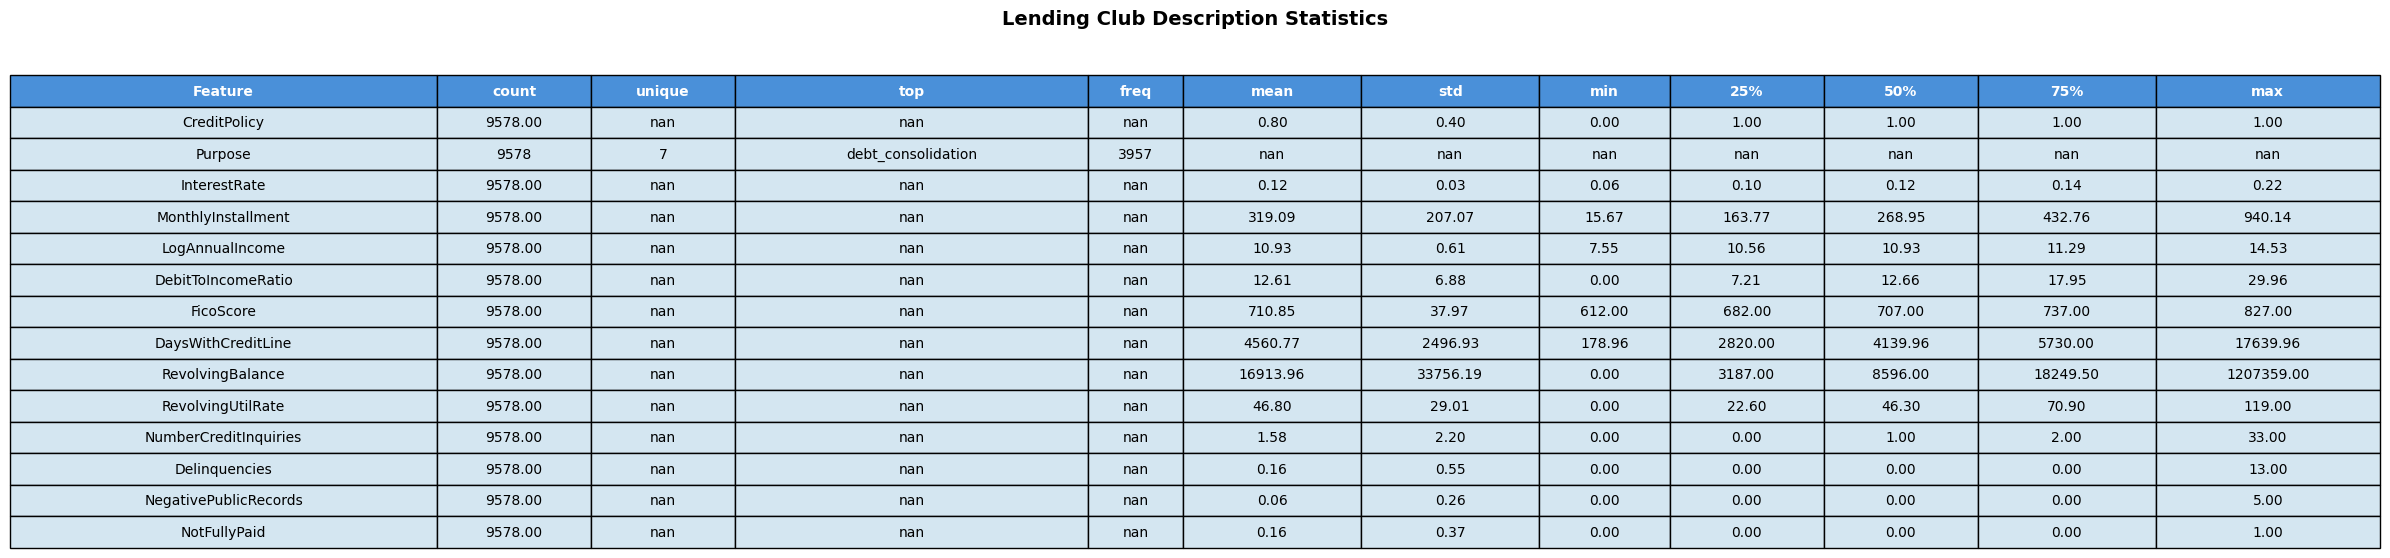

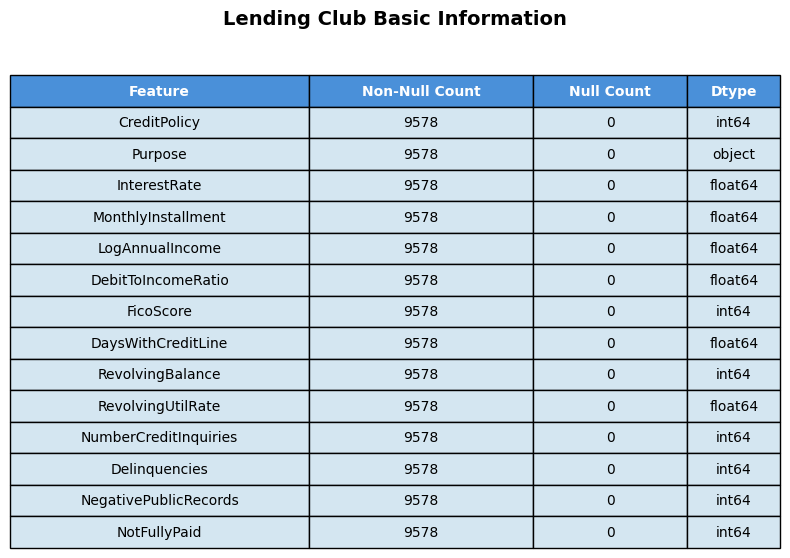

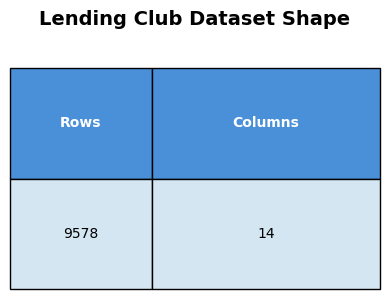




No data to display: Lending Club Missing Categorical (String) Data

No data to display: Lending Club Missing Numeric Data



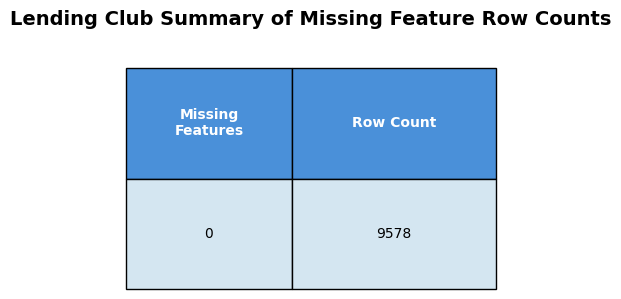

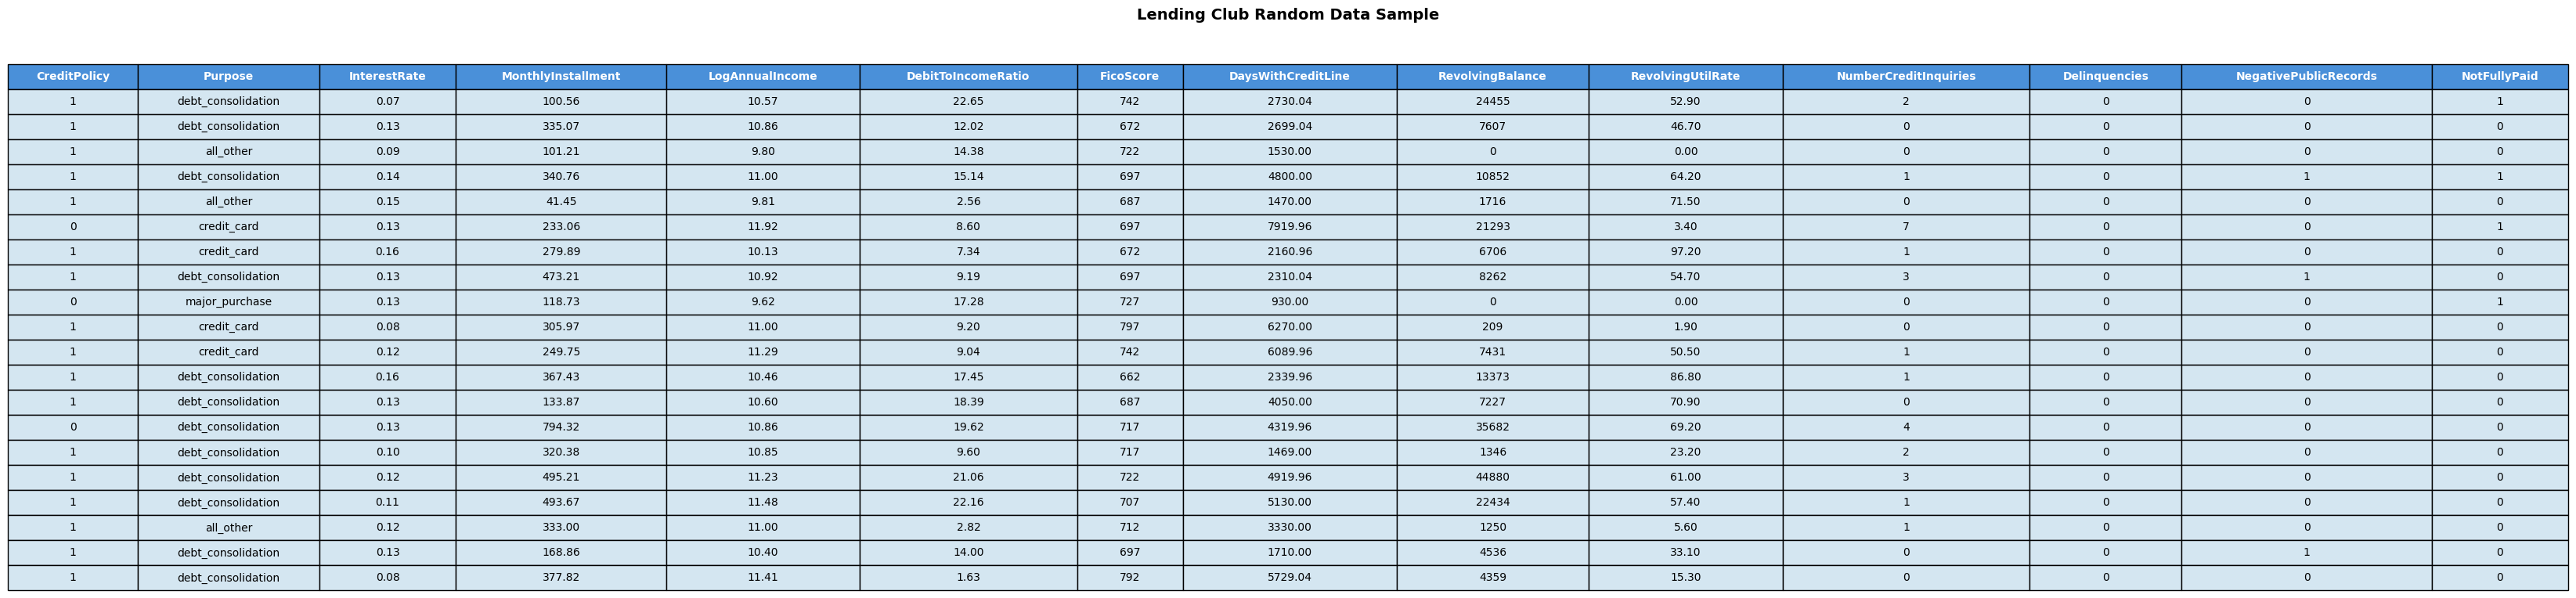

In [95]:
# Update Feature Names
label = 'NotFullyPaid'
features = ['CreditPolicy', 'Purpose', 'InterestRate','MonthlyInstallment', 'LogAnnualIncome', 'DebitToIncomeRatio', 'FicoScore', 'DaysWithCreditLine', 
            'RevolvingBalance', 'RevolvingUtilRate', 'NumberCreditInquiries', 'Delinquencies', 'NegativePublicRecords', 'NotFullyPaid' ]

df_LendingClub.columns = features

features.remove(label)
PrintDataFrameStatistics(df_LendingClub)

### **Initial EDA Analysis** ###
- Data - 9579 rows of data, 13 features (columns), 1 labels
- No rows of missing or (nan) data in either dataset
- Need to leading/following trim() categorical feature columns

#### Plots To Further Examine Data and Distributions ####
Display some initial Bar/Count Plots to give us an insight into any trends such as:
- Distribution of Loan Purposes
- Distribution of continuous numerical features including (InterestRate, MonthlyInstallment, FicoScore)
- Distribution of binary (integer) features such as (NumberOfCreditInquires, Delinquencies)

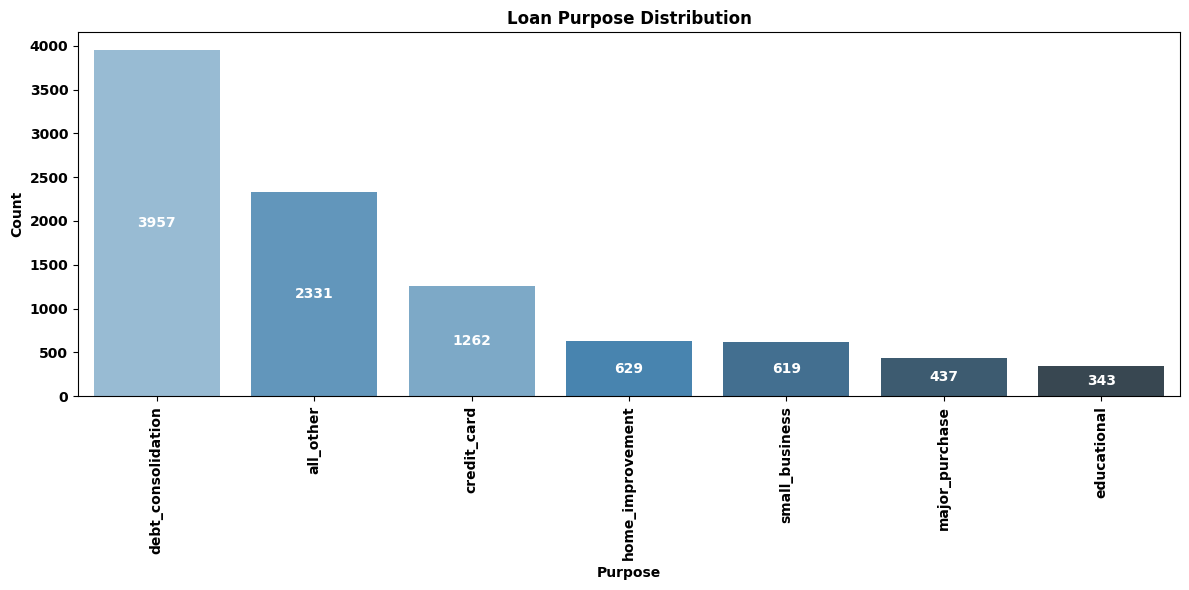

In [96]:
#
# Loan Purpose Distribution
# print(df_LendingClub['Purpose'].unique())
# print(df_LendingClub['Purpose'].value_counts())
# print(df_LendingClub['Purpose'].nunique())

purpose_order = df_LendingClub['Purpose'].value_counts().index
DisplayCountPlot(df_LendingClub, 'Purpose', purpose_order, 'Loan Purpose Distribution', (12,6))

#### Loan Purpose Distribution Analysis ####
- debit_consolidation accounts for the most loans (**41%**)
- all_other (**24%**) and credit_card (**13%**) are next highest 
- All together, they account for **78%** of all the loan types

#### Histograms of Continuous Numeric Features ####

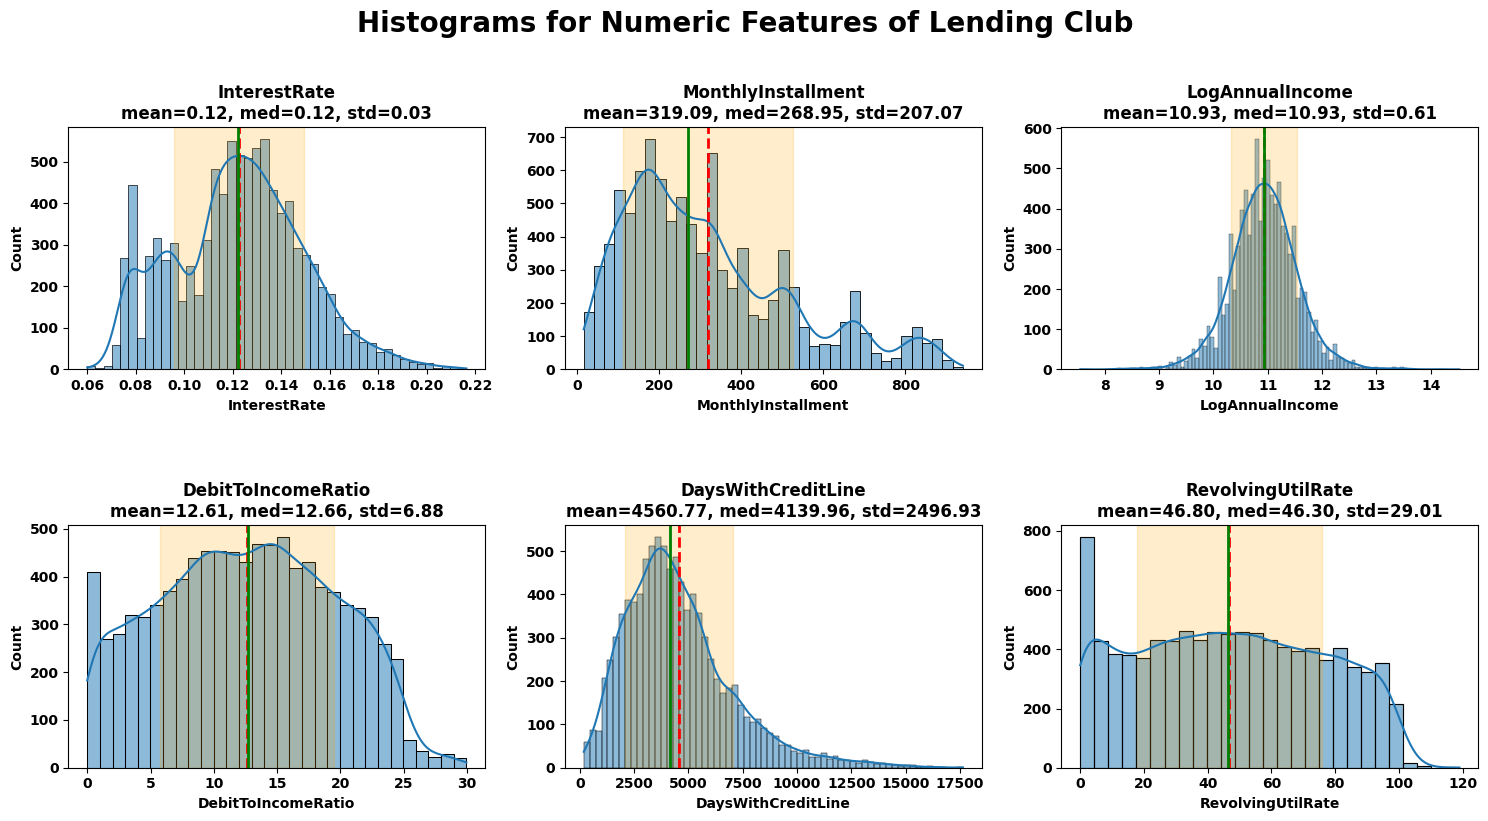

In [97]:
# Get a list of the float columns
float_columns = df_LendingClub.select_dtypes(include=['float']).columns.tolist()
#print(float_columns)

DisplayNumericFeatureHistograms(df_LendingClub, 
                                feature_columns=float_columns,
                                plot_title = 'Continuous Numeric Feature Distributions', 
                                display_statistics=True)

#### Continuous Numeric Feature Histograms Analysis ####
- InterestRate
    - Bimodal Distribution with Right Skew
- MonthlyInstallment
    - Right Skewed Distribution with a second peak around 270
- LogAnnualIncome
    - Perfect Normal Distribution - because it's Log...
    - Mean/Medium **10.93**
- DebitToIncomeRatio
    - Approximately Normal (Symmeteric) Distribution with a spike around 0
- DaysWithCreditLine
    - Normalish Right-Skewed Distribution
- RevolvingUtilRate
    - Uniform Distribtution with a spike at 0 and quick right tail after 100

**Action Item**: Normalize all the non-normal distributions during **Feature Engineering**

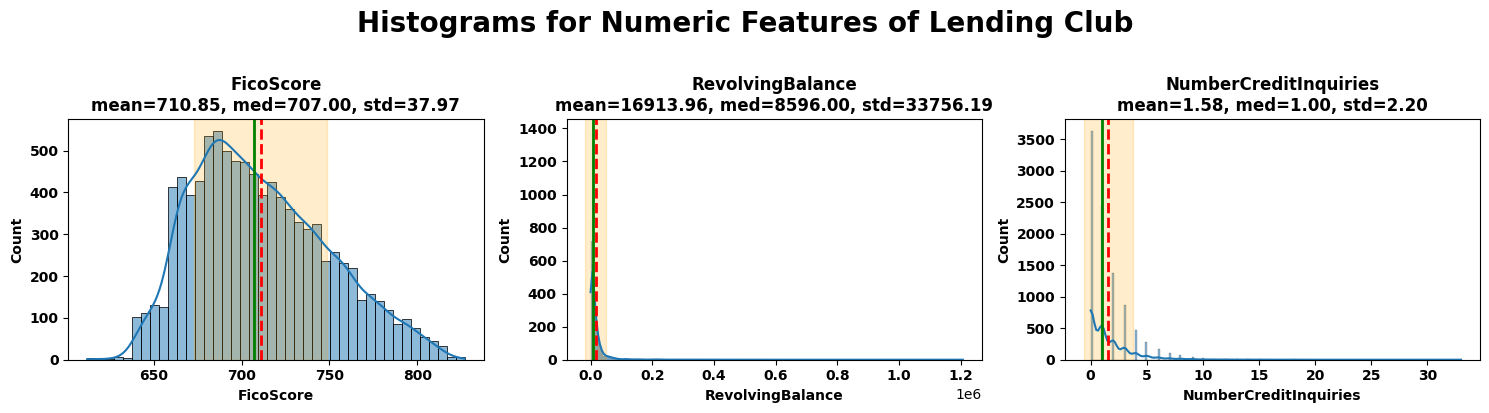

In [98]:
# Get a list of the continuous int feature columns
columns_to_plot = ['FicoScore', 'RevolvingBalance', 'NumberCreditInquiries']

DisplayNumericFeatureHistograms(df_LendingClub, 
                                feature_columns=columns_to_plot,
                                plot_title = 'Continuous Integer Feature Distributions', 
                                display_statistics=True)

#### Continuous Integer Feature Distributions Analysis ####
- FicoScore
    - Approximate Normal Distribution with a definite right skew
- RevolvingBalance
    - Heavily Right Skewed Distribution with extreme outliers
- NumberCreditInquiries
    - Right Skewed Distribution with extreme outliers

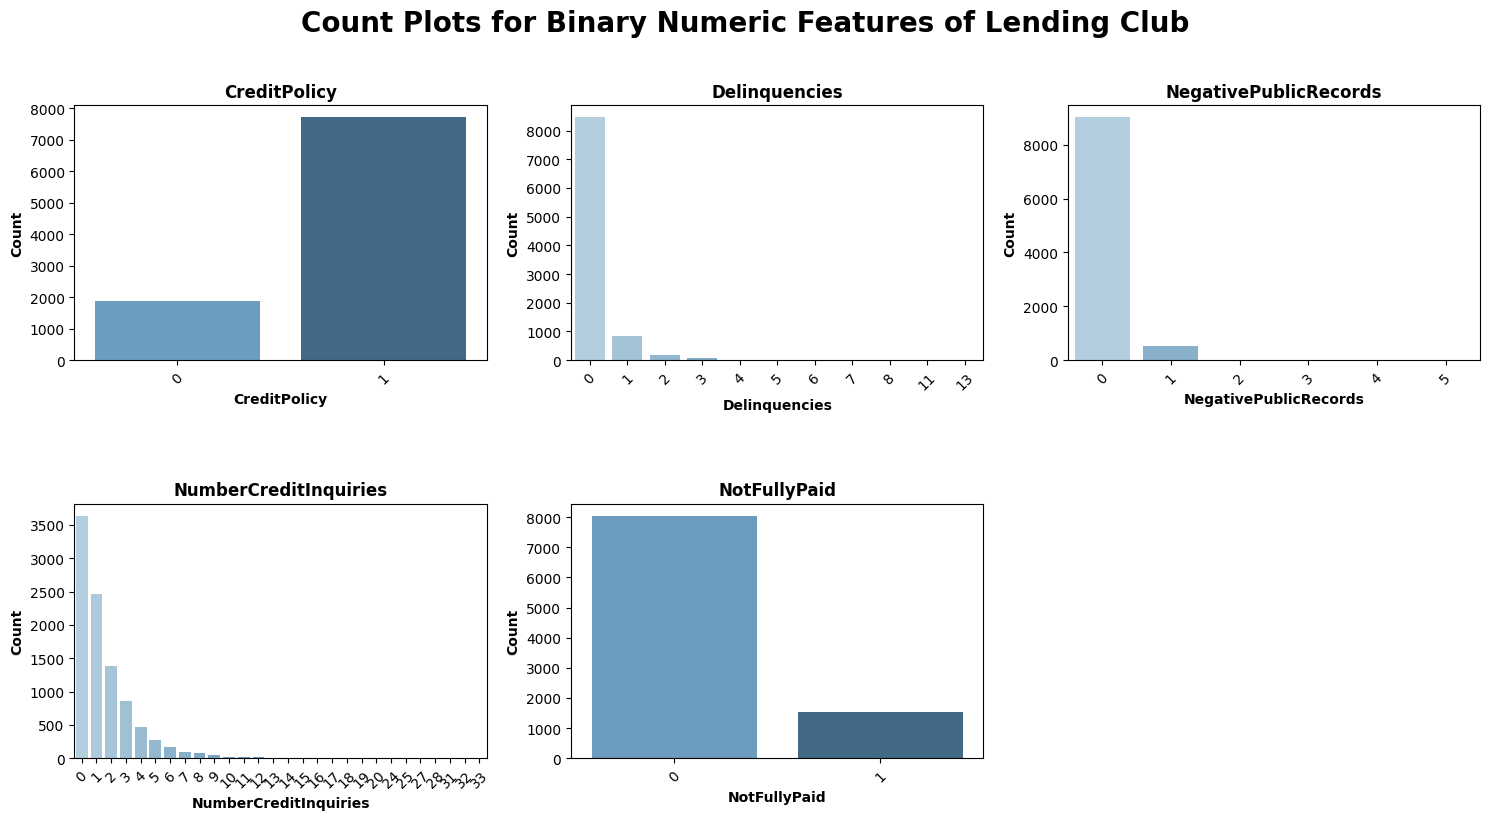

In [99]:
# Get a list of the integer columns
#integer_columns = df_LendingClub.select_dtypes(include=['int']).columns.tolist()
#print(integer_columns)
columns_to_plot = ['CreditPolicy', 'Delinquencies', 'NegativePublicRecords', 'NumberCreditInquiries', 'NotFullyPaid']

DisplayNumericFeatureCountPlots(df_LendingClub,
                                columns_to_plot,
                                target_label=None,
                                plot_title=data_set_name)


#### Count Plot Feature Distributions Analysis ####
- CreditPolicy
    - Most people (**80%)** meet the credit underwriting criteria
- Delinquencies
    - Most people do not have delinquencies
- NegativePublicRecords
    - Most people do not have negative public records
- NumberCreditInquiries
     -Right Skewed Distribution with extreme outliers
- NotFullyPaid
    - Imbalanced - Majority of people are not fully paid

#### Unbalanced Distribution of Dataset Label: **NotFullyPaid**
Display plots showing the distribution of the label (NotFullyPaid).</br>
The plots clearly show in the intended label that far more people **DID NOT** fully pay their loans</br>
This will have to be dealt with later on in the **Feature Engineering**

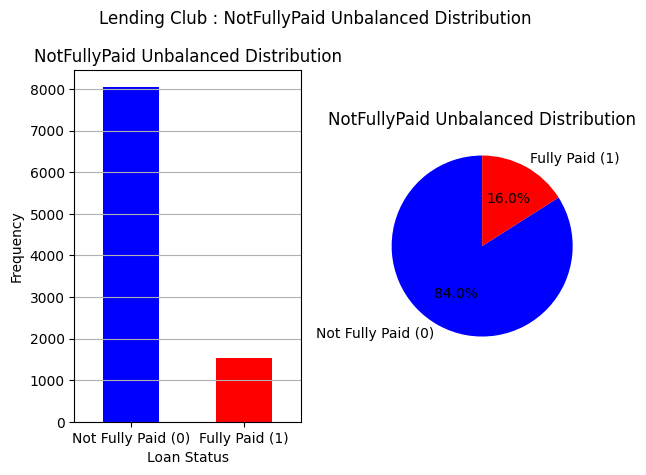

In [100]:
def DisplayDataFeatureBalancePlots(x_data, y_data, plot_title, label_name):

    sub_plot_title = f"{label_name} Unbalanced Distribution"

    leftCounts = y_data.value_counts().sort_index()

    plt.subplot(1, 2, 1)
    leftCounts.plot(kind='bar', color=['blue', 'red'])
    plt.title(sub_plot_title)
    plt.xlabel('Loan Status')
    plt.ylabel('Frequency')
    plt.xticks(ticks=[0, 1], labels=['Not Fully Paid (0)', 'Fully Paid (1)'], rotation=0)
    plt.grid(axis='y')

    # Plot the distribution of the 'Class' column as a pie chart
    plt.subplot(1, 2, 2)
    leftCounts.plot(kind='pie', labels=['Not Fully Paid (0)', 'Fully Paid (1)'], colors=['blue', 'red'], autopct='%1.1f%%', startangle=90)
    plt.title(sub_plot_title)
    plt.ylabel('')

    plt.suptitle(plot_title)

    # Show the plots
    plt.tight_layout()
    plt.show()
    print()

    if x_data is not None:
        print("Scatter Plot Unbalanced Data")
        # Scatter plot for the imbalanced data
        plt.figure(figsize=(12, 5))
        plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data, alpha=0.5, cmap='viridis', marker='o')
        plt.title(title)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.colorbar(label='Class')
    print()
    print()

DisplayDataFeatureBalancePlots(x_data=None, 
                               y_data=df_LendingClub[label], 
                               plot_title= f'{data_set_name} : {label} Unbalanced Distribution',
                               label_name = label)

## **2. Non-Feature Engineered Modeling for Baseline** ##
Choose, justify and train a (1) Machine Learning model and a (1) Deep Learning Model. </br>
Train these models against unfeature engineered data. </br>
The Unfeature Engineered dataset will require the minimal amount of feature engineering required to get the models working.</br>
In a later section the same models will be run against **Feature Engineered** data.</br>

This will give the opportunity to make 2 comparisons:
1. Within each Un/Feature Engineered bucket, compare the **Machine Learning** and **Deep Learning Models**
2. Compare the overall performance (best model) results between the Unfeature and Feature Engineered buckets.

#### Limited Feature Engineering ####
Complete the minimum amount of feature engineering required to get the models to run.</br>
In this case we have to encode the string feature 'Purpose' to numeric values.

In [101]:
# One-Hot-Encode Purpose - no implied ordinal ranking
df_LendingClub = pd.get_dummies(df_LendingClub, columns=['Purpose'], drop_first=True, dtype=int)

### Test-Train Split ###

In [102]:
# # Separate features and target variable
X = df_LendingClub.drop(label, axis=1)
y = df_LendingClub[label]

# Test/Train Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

## **3. Non-Feature Engineered Modeling for Baseline** ##
### Machine Learning Models ###
I will examine/compare the results of 3 Machine Learning models:
1. Logisitic Regression 
2. Random Forest Classifier
3. Gradient Boosting Classifier

#### Machine Learning Utility Functions ####
These utility functions were taken directly from my "**Machine Learning - Unit 3 End Project**" </br>
Ultimately (when time permits -- **HA**!) I would like to place these reoccurring functions in a private utility library.

In [103]:
#
# LogisticRegression
# 
def RunLogisticRegression(df_target=None, target_label=None, plot_title=None, 
                          apply_scaling=False, apply_pca=False,
                          X_train=None, X_test=None, y_train=None, y_test=None,
                          feature_names=None):
    
    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:

        X = None 
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns
        
        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()

    # Balanced Class Weight 
    model = LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} LOGISTIC REGRESSION RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report (includes precision, recall, F1)
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Logistic Regression - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Feature Importance
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    avg_importance = pd.Series(
        np.abs(model.coef_).mean(axis=0),
        index=feature_names
    ).sort_values(ascending=False)
    
    print(avg_importance)
    print()

    plt.figure(figsize=(10, 6))
    avg_importance.sort_values().plot(kind='barh')
    plt.xlabel('Average Absolute Coefficient')
    plt.title(f'{plot_title} Feature Importance - Logistic Regression', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }


#
# RandomForestClassifier
# 
def RunRandomForestClassifier(df_target=None, target_label=None, plot_title=None, 
                              apply_scaling=False, apply_pca=False,
                              X_train=None, X_test=None, y_train=None, y_test=None,
                              feature_names=None):

    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:
        X = None
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns

        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # PCA - after scaling, before model
        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()             

    # Balanced Class Weight 
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=315,
        n_jobs=-1,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} RANDOM FOREST CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Random Forest - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Feature Importance
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # RandomForest uses feature_importances_ (not coef_)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance (Gini)')
    plt.title(f'{plot_title} Feature Importance - Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }

#
# GradientBoostingClassifier
# 
def RunGradientBoostingClassifier(df_target=None, target_label=None, plot_title=None, 
                                  apply_scaling=False, apply_pca=False,
                                  X_train=None, X_test=None, y_train=None, y_test=None,
                                  feature_names=None):

    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:
        X = None
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns

        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # PCA - after scaling, before model
        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()

    # Gradient Boosting Classifier
    # Note: GradientBoostingClassifier does not support class_weight parameter
    # Using SMOTE data handles class imbalance instead
    model = GradientBoostingClassifier(
                                        n_estimators=100,
                                        learning_rate=0.1,
                                        max_depth=3,
                                        min_samples_split=2,
                                        min_samples_leaf=1,
                                        max_features='sqrt',
                                        random_state=315
                                    )
    model.fit(X_train, y_train)

    #
    # Predictions
    #
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    #
    # Metrics
    #
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} GRADIENT BOOSTING CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    #
    # Classification Report (includes precision, recall, F1)
    #
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    #
    # Confusion Matrix
    #
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Gradient Boosting - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    #
    # Feature Importance
    #
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # GradientBoosting uses feature_importances_ (like RandomForest)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance')
    plt.title(f'{plot_title} Feature Importance - Gradient Boosting', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }

def PlotConfusionMatrices(results_dict):
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    palettes = ['Blues', 'Greens', 'Oranges', 'Purples']
    
    for i, (name, results) in enumerate(results_dict.items()):
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        cm = confusion_matrix(y_test, test_predictions)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap=palettes[i % len(palettes)], 
                    ax=axes[i], cbar=True)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    
    plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print()

def CompareClassificationResults(results_dict, title='Classifier Comparison'):
    
    sns.set_style("whitegrid")
    
    #
    # 1. Calculate all metrics
    #
    metrics_data = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        report = results['report']
        
        metrics_data.append({
            'Model': name,
            'Train Accuracy': results['train_accuracy'],
            'Test Accuracy': results['test_accuracy'],
            'Balanced Accuracy': balanced_accuracy_score(y_test, test_predictions),
            'Precision': precision_score(y_test, test_predictions, average='weighted'),
            'Recall': recall_score(y_test, test_predictions, average='weighted'),
            'F1 Score': results['f1_score'],
            'Gap': results['train_accuracy'] - results['test_accuracy']
        })
    
    df_comparisons = pd.DataFrame(metrics_data).set_index('Model')
    
    #
    # 2. Print Metrics Table
    #
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(df_comparisons.round(4))
    print()

    DisplayTable(df_comparisons, 'Classification Comparisons',show_index=True)
    
    #
    # 3. Accuracy Comparison (Train vs Test vs Balanced)
    #
    accuracy_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        accuracy_metrics.append({'Model': name, 'Metric': 'Train Accuracy', 'Score': results['train_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Test Accuracy', 'Score': results['test_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Balanced Accuracy', 'Score': balanced_accuracy_score(y_test, test_predictions)})
    
    acc_df = pd.DataFrame(accuracy_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=acc_df, x='Metric', y='Score', hue='Model', palette='deep')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Accuracy Metrics Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 4. Precision / Recall / F1 Comparison
    #
    prf_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        prf_metrics.append({'Model': name, 'Metric': 'Precision', 'Score': precision_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'Recall', 'Score': recall_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'F1 Score', 'Score': results['f1_score']})
    
    prf_df = pd.DataFrame(prf_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 5. Gap Comparison (Overfitting indicator)
    #
    gap_data = pd.DataFrame({
        'Model': list(results_dict.keys()),
        'Gap': [r['train_accuracy'] - r['test_accuracy'] for r in results_dict.values()]
    })
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')
    ax.bar_label(ax.containers[0], fmt='%.4f', fontsize=10)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Overfitting Indicator (Lower is Better)', fontweight='bold')
    plt.ylabel('Train - Test Accuracy Gap')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 6. Confusion Matrices
    #
    PlotConfusionMatrices(results_dict)
    
    #
    # 7. Metrics Heatmap
    #
    plt.figure(figsize=(12, len(results_dict) * 0.8 + 2))
    heatmap_cols = ['Test Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
    sns.heatmap(df_comparisons[heatmap_cols], annot=True, fmt='.4f', cmap='YlGnBu', 
                vmin=0, vmax=1, linewidths=0.5)
    plt.title('Model Metrics Heatmap', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #
    # 8. Plot Classification Report Results
    #
    for i, (name, results) in enumerate(results_dict.items()):

        report = results['report']
        df_result = pd.DataFrame(report)
        DisplayTable(df_result, 
                     f'{name} Classification Report',
                     show_index=True)
    
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

    if n_models == 1:
        axes = [axes]

    for i, (name, results) in enumerate(results_dict.items()):
        report = results['report']
        df_report = pd.DataFrame(report).T
        
        # Keep only class rows and main metrics
        df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
        df_report = df_report.drop(columns=['support'], errors='ignore')
        
        sns.heatmap(df_report, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=axes[i], linewidths=0.5)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_ylabel('Class')
        axes[i].set_xlabel('Metric')

    plt.suptitle('Classification Reports Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return df_comparisons

def CheckClusterDistributions(df_target, feature_name, title):
    print(f'{title} Cluster Distribution Comparisons')
    valueCounts = df_target[feature_name].value_counts()
    print(f'ValueCounts: {valueCounts}')
    normalizedValueCounts = df_target[feature_name].value_counts(normalize=True) * 100
    print(f'NormalizedValueCounts: {normalizedValueCounts}')
    print()

#### Cross Validation Utility Functions ####
These utility functions were taken directly from my "**Machine Learning - Unit 3 End Project**" </br>

In [104]:
def ApplyCrossValidationClassification(model, X, y, plot_label):

    # Split for train/test calculation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    # Fit model and calculate train/test metrics
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    test_f1 = f1_score(y_test, model.predict(X_test), average='weighted')

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validation for Accuracy
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', n_jobs=-1, cv=kf)

    # Cross-validation for F1 Score
    cv_f1 = cross_val_score(model, X, y, scoring='f1_weighted', n_jobs=-1, cv=kf)

    # Accuracy stats
    acc_mean = np.mean(cv_accuracy)
    acc_std = np.std(cv_accuracy)
    acc_moe = 1.96 * acc_std / np.sqrt(len(cv_accuracy))

    # F1 stats
    f1_mean = np.mean(cv_f1)
    f1_std = np.std(cv_f1)
    f1_moe = 1.96 * f1_std / np.sqrt(len(cv_f1))

    print(plot_label)
    print(f'Mean CV Accuracy: {acc_mean:.4f} ± {acc_moe:.4f}')
    print(f'95% CI Accuracy: {acc_mean - acc_moe:.4f} to {acc_mean + acc_moe:.4f}')
    print(f'Mean CV F1 Score: {f1_mean:.4f} ± {f1_moe:.4f}')
    print(f'95% CI F1: {f1_mean - f1_moe:.4f} to {f1_mean + f1_moe:.4f}')
    print(f'Train Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'Test F1 Score: {test_f1:.4f}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy boxplot
    axes[0].boxplot(cv_accuracy)
    axes[0].axhline(acc_mean - acc_moe, linestyle='--', color='teal', label='95% CI')
    axes[0].axhline(acc_mean + acc_moe, linestyle='--', color='teal')
    axes[0].axhline(test_accuracy, color='purple', label='Test Accuracy')
    axes[0].axhline(train_accuracy, color='red', label='Train Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'CV Accuracy - {plot_label}')
    axes[0].legend(loc='best')

    # F1 boxplot
    axes[1].boxplot(cv_f1)
    axes[1].axhline(f1_mean - f1_moe, linestyle='--', color='teal', label='95% CI')
    axes[1].axhline(f1_mean + f1_moe, linestyle='--', color='teal')
    axes[1].axhline(test_f1, color='purple', label='Test F1')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title(f'CV F1 Score - {plot_label}')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

    print()
    print()

    return {'cv_accuracy': cv_accuracy, 'cv_f1': cv_f1}

### Machine Learning Baseline Models ###
#### Logistic Regression ####

Logistic Regression


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Lending Club Loan Data LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.6595
Testing Accuracy:  0.6644
Testing F1 Score:  0.7049
Gap:               -0.0049

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8856, 'recall': 0.6888612321095209, 'f1-score': 0.7749387469373469, 'support': 1607.0}, '1': {'precision': 0.24924924924924924, 'recall': 0.5372168284789643, 'f1-score': 0.3405128205128205, 'support': 309.0}, 'accuracy': 0.6644050104384134, 'macro avg': {'precision': 0.5674246246246246, 'recall': 0.6130390302942426, 'f1-score': 0.5577257837250837, 'support': 1916.0}, 'weighted avg': {'precision': 0.7829734958340386, 'recall': 0.6644050104384134, 'f1-score': 0.7048773631872536, 'support': 1916.0}}



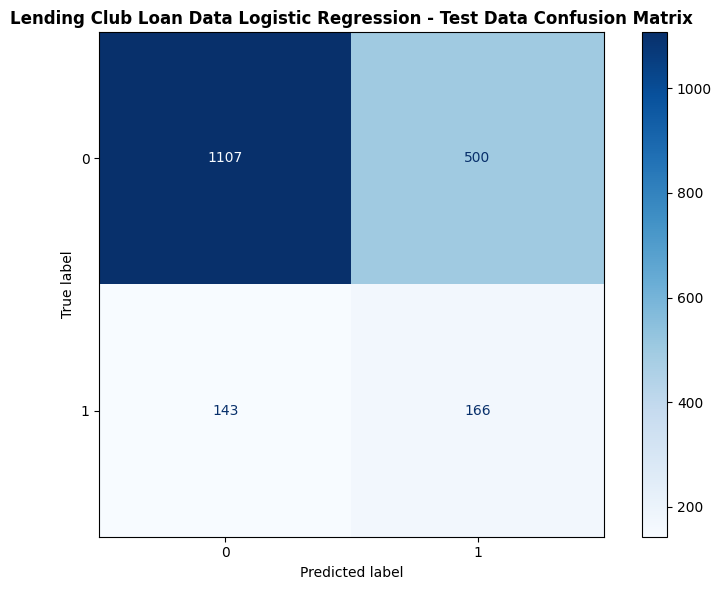


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
Purpose_credit_card           0.624816
Purpose_small_business        0.581148
CreditPolicy                  0.503365
NegativePublicRecords         0.263626
Purpose_educational           0.214567
Purpose_debt_consolidation    0.200979
Purpose_major_purchase        0.169880
NumberCreditInquiries         0.116391
Delinquencies                 0.092750
InterestRate                  0.091086
LogAnnualIncome               0.048470
Purpose_home_improvement      0.021128
RevolvingUtilRate             0.009079
DebitToIncomeRatio            0.004732
MonthlyInstallment            0.000847
FicoScore                     0.000091
DaysWithCreditLine            0.000034
RevolvingBalance              0.000001
dtype: float64



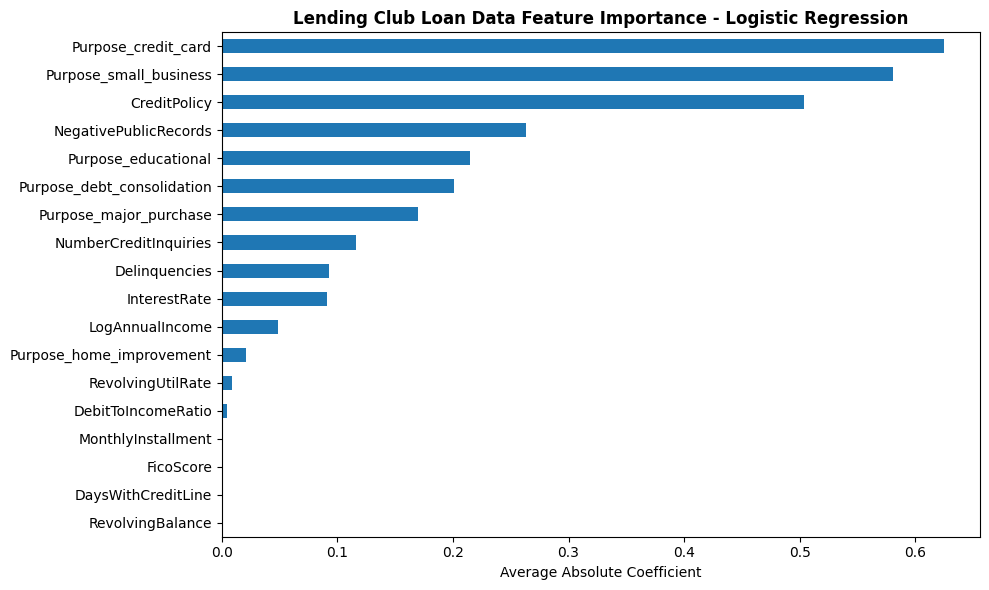

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression 5-Fold CV
Mean CV Accuracy: 0.6587 ± 0.0125
95% CI Accuracy: 0.6462 to 0.6712
Mean CV F1 Score: 0.7012 ± 0.0124
95% CI F1: 0.6888 to 0.7136
Train Accuracy: 0.6484
Test Accuracy: 0.6510
Test F1 Score: 0.6953


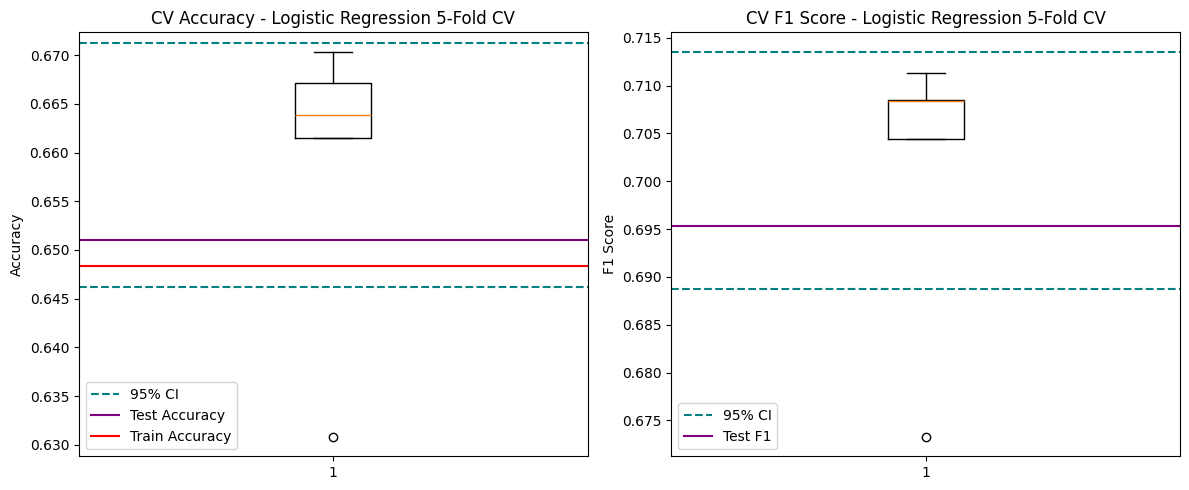

{'cv_accuracy': array([0.66144814, 0.6307893 , 0.66383812, 0.66710183, 0.67036554]),
 'cv_f1': array([0.70439633, 0.67325625, 0.71136198, 0.70846128, 0.70838098])}

In [105]:
# Get feature names before scaling (from original X)
#feature_names = X.columns  #
feature_names=X_train.columns.tolist()

# Call with SMOTE data
print('Logistic Regression')
logisticRegressionResults = RunLogisticRegression(
                                                    plot_title='Lending Club Loan Data',
                                                    X_train=X_train,     
                                                    X_test=X_test,          
                                                    y_train=y_train,     
                                                    y_test=y_test,             
                                                    feature_names=feature_names
                                                )

ApplyCrossValidationClassification(
                                    logisticRegressionResults['model'], 
                                    X_train,     
                                    y_train,      
                                    'Logistic Regression 5-Fold CV'
                                )

#### Random Forest Classifier ####

In [106]:
print('Random Forest Classifier')
randomForestResults = RunRandomForestClassifier(
                                                plot_title='Lending Club Loan Data',
                                                X_train=X_train,     
                                                X_test=X_test,          
                                                y_train=y_train,     
                                                y_test=y_test,             
                                                feature_names=feature_names
                                            )

# Cross-validation
ApplyCrossValidationClassification(
                                    randomForestResults['model'], 
                                    X_train,      
                                    y_train,      
                                    'Random Forest 5-Fold CV'
                                )

print()

Random Forest Classifier


NameError: name 'RandomForestClassifier' is not defined

#### Gradient Boosting Classifier ####

In [ ]:
# Call with SMOTE data
print('Gradient Boosting Classifier')
gradientBoostingResults = RunGradientBoostingClassifier(
                                                        plot_title='Lending Club Loan Data',
                                                        X_train=X_train,     
                                                        X_test=X_test,          
                                                        y_train=y_train,     
                                                        y_test=y_test,             
                                                        feature_names=feature_names
                                                    )

# Cross-validation
ApplyCrossValidationClassification(
                                    gradientBoostingResults['model'], 
                                    X_train,      
                                    y_train,      
                                    'Gradient Boosting 5-Fold CV'
                                )

## **3. Data Wrangling and Feature Engineering** ##

### **Missing Values and Imputation** ###
Not required

##### **Trim Categorical Features** #####

In [ ]:
# Trim Data
obj_cols = df_LendingClub.select_dtypes(include='object').columns
df_LendingClub[obj_cols] = df_LendingClub[obj_cols].apply(lambda col: col.str.strip())

### **New Feature Creation** ###
- None Required

### **Data Type Conversion** ###
For OS memory performance and model efficiency, convert to more efficient data types.

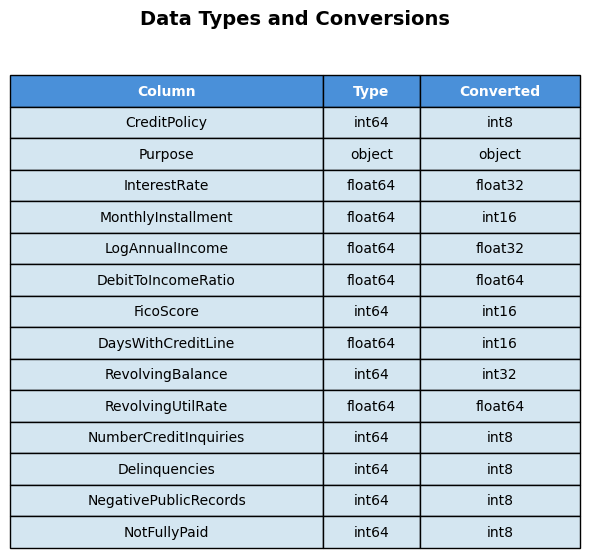




Converted Data Columns


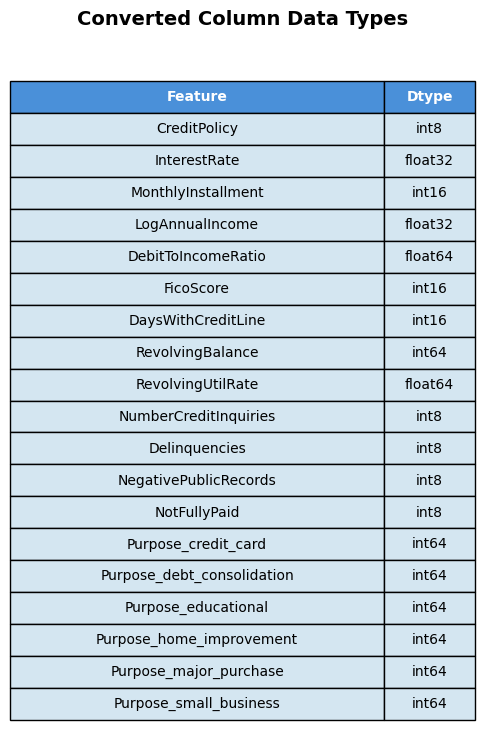

In [ ]:
#print(df_Merged.dtypes)

features = ['CreditPolicy', 'Purpose', 'InterestRate','MonthlyInstallment', 'LogAnnualIncome', 'DebitToIncomeRatio', 'FicoScore', 
            'DaysWithCreditLine', 'RevolvingBalance', 'RevolvingUtilRate', 'NumberCreditInquiries', 'Delinquencies', 'NegativePublicRecords', 'NotFullyPaid' ]
# Features, Types and Data Type Conversion Targets..
df_types = pd.DataFrame({
                    'Column': features,
                    'Type': [
                        'int64', 'object', 'float64', 'float64', 'float64', 'float64', 'int64', 
                        'float64', 'int64', 'float64', 'int64', 'int64', 'int64', 'int64'
                    ],
                    'Converted': [
                        'int8', 'object', 'float32', 'int16', 'float32', 'float64', 'int16', 
                        'int16', 'int32', 'float64', 'int8', 'int8', 'int8', 'int8'
                    ]
                })


#print(df_types)

DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)
print()


def PerformDataConversion(df_target, display_output=False):

    # Convert Floats
    float_columns = ['InterestRate', 'LogAnnualIncome']
    df_target[float_columns] = df_target[float_columns].astype('float32')

    # Convert Int64 to Int16
    int_columns = ['FicoScore']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    # Convert Int64 to Int8
    int_columns = ['CreditPolicy', 'NumberCreditInquiries', 'Delinquencies', 'NegativePublicRecords', 'NotFullyPaid']
    df_target[int_columns] = df_target[int_columns].astype('int8')

    # Convert (Round) Float to Int16
    int_columns = ['MonthlyInstallment', 'DaysWithCreditLine']
    df_target[int_columns] = df_target[int_columns].round(0).astype('int16')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_LendingClub = PerformDataConversion(df_LendingClub, display_output=True)
#PrintDataFrameStatistics(df_LendingClub)

#### Feature Encoding ####

In [ ]:
# One-Hot-Encode Purpose - no implied ordinal ranking
df_LendingClub = pd.get_dummies(df_LendingClub, columns=['Purpose'], drop_first=True, dtype=int)
#PrintDataFrameStatistics(df_LendingClub)

KeyError: "None of [Index(['Purpose'], dtype='object')] are in the [columns]"

### Feature Normalization ###

### Deal with Imbalances ###

## **3. Prepare for Model Processing** ##

##### **Train/Test Split** #####

In [ ]:
# # Separate features and target variable
X = df_LendingClub.drop('left', axis=1)
y = df_LendingClub['left']

# Test/Train Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)


##### **Standard Scale** #####

In [ ]:
# Update the Features List
features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 
            'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain' ]

# Scale the features
scaler = StandardScaler()
scaler.fit(df_training[features])

df_training[features] = scaler.transform(df_training[features])
df_testing[features] = scaler.transform(df_testing[features])

## **4. Logistic Regression Baseline** ##
Create a baseline model to compare against the neural network.

##### **Create Model/Fit** #####

In [ ]:
lr_model = LogisticRegression(n_jobs=-1)
fit_result = lr_model.fit(df_training[features], df_training[label])

##### **Test Set Evaluation** #####

In [ ]:
# Evaluate on test set
logistic_predictions = lr_model.predict(df_testing[features])
logistic_rsquared = lr_model.score(df_testing[features], df_testing[label])
print(f'Linear regression R² on test set: {logistic_rsquared:.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(df_testing[label], logistic_predictions, ax=ax, cmap='Blues')
plt.title('Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()

**Logistic Regression Confusion Matrix Analysis** 
- Model is good at predicting customers who stay (1920)
- Model is bad at catching customers who actually leave (miss 399 of 497)

## **Task 4: Keras Sequential API Model** ##
- Supporting Functions "Borrowed" from Lesson_28_activity...

##### **Class Weights for Label class imbalance** #####
Class weights to boost minority classes errors so both classes are equally important

In [ ]:
# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_training[label]),
    y=df_training[label]
)

class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')

##### **Callback Function Constructors** #####

In [ ]:
def MakeCallbacks(
    learning_rate: float,
    batch_size: int,
    patience: int = 10,
) -> Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]:

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=verbose
    )

    run_log_dir = f'{log_dir}/lr_{learning_rate}_bs_{batch_size}'

    Path(run_log_dir).mkdir(parents=True, exist_ok=True)

    tensorboard_callback = keras.callbacks.TensorBoard(
        log_dir=run_log_dir,
        histogram_freq=1,
        write_graph=False
    )

    return early_stopping, tensorboard_callback

##### **Model Constructor Function** #####
- Activation Functions: - Decides whether neuron fires not. Introduces nonlinearity into model</br>
    1) **ReLU**  - for hidden layers; computationally efficient; outputs if positive, otherwise 0; maintains gradient
    2) **Sigmoid** - Used for binary classification of output layer; probability between 0 and 1
- Optimizer: - Adjusts model weights during training to minimize loss function.</br>
    1) **Adam Optimizer** - automatically adjusts during training; faster convergence</br>
- Loss: - how to measure difference between predictions and actual values</br>
    1) **binary_crossentropy** - specifically for binary classification problems where output is **0** or **1**
- Metrics: - used to track model performance during training and evaluation.
    1) accur**acy - accuracy is used for classification. In this case for binary classification I should have explicitly </br>
                  selected binary_accuracy; But Keras detects **binary_crossentropy** and automatically interprets **accuracy** </br>
                  to be **binary_accuracy**


In [ ]:
def BuildModel(learning_rate: float=0.01) -> keras.Sequential:

    # model = keras.Sequential([
    #     layers.Input(shape=(11,)),
    #     layers.Dense(16, activation='relu'),
    #     layers.Dense(32, activation='relu'),
    #     layers.Dense(16, activation='relu'),
    #     layers.Dense(1, activation='sigmoid')
    # ])

    # Something more complex
    model = keras.Sequential([
        layers.Input(shape=(11,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    # Try simpler model
    # model = keras.Sequential([
    #     layers.Input(shape=(11,)),
    #     layers.Dense(8, activation='relu'),
    #     layers.Dense(4, activation='relu'),
    #     layers.Dense(1, activation='sigmoid')
    # ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

##### **Model Training Function** #####
Architecture directly from George and Assignment_28. </br>
Unfortunately not enough time to explore KerasTuner, </br>
so I followed existing pattern to do some basic hyperparameter tuning.

In [ ]:
def TrainModel(
    model: keras.Sequential,
    epochs: int=200,
    batch_size: int=128,
    validation_split: Optional[float]=0.2,
    callbacks: Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]=None
) -> Tuple[keras.Sequential, keras.callbacks.History]:

    history = model.fit(
        df_training[features],
        df_training[label],
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history

##### **Train the Model** #####

In [ ]:

batch_sizes = [256, 512, 1024]
learning_rates = [1e-6, 1e-5, 1e-4]

for batch_size, learning_rate in itertools.product(batch_sizes, learning_rates):

    print(f'Batch size: {batch_size}, learning rate: {learning_rate}...', end='\t')

    # Set-up callback for this run
    callbacks = MakeCallbacks(learning_rate=learning_rate, batch_size=batch_size)

    # Build and train the model
    model = BuildModel(learning_rate=learning_rate)
    model, history = TrainModel(model, batch_size=batch_size, callbacks=callbacks)

    print(f"final val loss: {history.history['val_loss'][-1]:.4f}, ", end=' ') 
    print(f"final val accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

print()

### **Experimented with Model Complexity** ###
#### **Results from Hidden Layer/Neuron Experimenting** ####


##### Model Configuration #1 #####
model = keras.Sequential([ </br>
    layers.Input(shape=(11,)), </br>
    layers.Dense(16, activation='relu'),  </br>
    layers.Dense(32, activation='relu'),  </br>
    layers.Dense(16, activation='relu'),  </br>
    layers.Dense(1, activation='sigmoid')])  </br>
##### Results #####
Batch size: 256, learning rate: 1e-06...	final val loss: 0.7204,  final val accuracy: 46.20%  </br>
Batch size: 256, learning rate: 1e-05...	final val loss: 0.6143,  final val accuracy: 66.00% </br>
**Batch size: 256, learning rate: 0.0001...	final val loss: 0.4565,  final val accuracy: 77.33%** </br>
Batch size: 512, learning rate: 1e-06...	final val loss: 0.6885,  final val accuracy: 53.67% </br>
Batch size: 512, learning rate: 1e-05...	final val loss: 0.6967,  final val accuracy: 55.27% </br>
Batch size: 512, learning rate: 0.0001...	final val loss: 0.6265,  final val accuracy: 72.33% </br>
Batch size: 1024, learning rate: 1e-06...	final val loss: 0.5975,  final val accuracy: 79.47% </br>
Batch size: 1024, learning rate: 1e-05...	final val loss: 0.8181,  final val accuracy: 24.60% </br>
Batch size: 1024, learning rate: 0.0001...	final val loss: 0.6241,  final val accuracy: 77.13% </br>

##### Model Configuration #2 #####
model = keras.Sequential([ </br>
    layers.Input(shape=(11,)), </br>
    layers.Dense(16, activation='relu'),  </br>
    layers.Dense(32, activation='relu'),  </br>
    layers.Dense(64, activation='relu'),  </br>
    layers.Dense(32, activation='relu'),  </br>
    layers.Dense(16, activation='relu'),  </br>
    layers.Dense(1, activation='sigmoid')])  </br>
##### Results #####
Batch size: 256, learning rate: 1e-06...	final val loss: 0.6955,  final val accuracy: 49.53% </br>
Batch size: 256, learning rate: 1e-05...	final val loss: 0.6621,  final val accuracy: 78.07% </br>
Batch size: 256, learning rate: 0.0001...	final val loss: 0.4681,  final val accuracy: 78.07% </br>
Batch size: 512, learning rate: 1e-06...	final val loss: 0.6374,  final val accuracy: 79.53% </br>
Batch size: 512, learning rate: 1e-05...	final val loss: 0.6235,  final val accuracy: 68.80% </br>
**Batch size: 512, learning rate: 0.0001...	final val loss: 0.4563,  final val accuracy: 77.73%** </br>
Batch size: 1024, learning rate: 1e-06...	final val loss: 0.6954,  final val accuracy: 44.40% </br>
Batch size: 1024, learning rate: 1e-05...	final val loss: 0.6677,  final val accuracy: 74.93% </br>
Batch size: 1024, learning rate: 0.0001...	final val loss: 0.4703,  final val accuracy: 78.27% </br>

##### Model Configuration #3 #####
model = keras.Sequential([ </br>
    layers.Input(shape=(11,)), </br>
    layers.Dense(8, activation='relu'), </br>
    layers.Dense(4, activation='relu'), </br>
    layers.Dense(1, activation='sigmoid')]) </br>

##### Results #####
Batch size: 256, learning rate: 1e-06...	final val loss: 0.7265,  final val accuracy: 53.13%<br>
Batch size: 256, learning rate: 1e-05...	final val loss: 0.7140,  final val accuracy: 54.20%<br>
Batch size: 256, learning rate: 0.0001...	final val loss: 0.5335,  final val accuracy: 73.40%<br>
Batch size: 512, learning rate: 1e-06...	final val loss: 0.6991,  final val accuracy: 46.47%<br>
Batch size: 512, learning rate: 1e-05...	final val loss: 0.6172,  final val accuracy: 74.07%<br>
Batch size: 512, learning rate: 0.0001...	final val loss: 0.7068,  final val accuracy: 49.20%<br>
Batch size: 1024, learning rate: 1e-06...	final val loss: 0.8385,  final val accuracy: 24.13%<br>
Batch size: 1024, learning rate: 1e-05...	final val loss: 0.6252,  final val accuracy: 68.60%<br>
***Batch size: 1024, learning rate: 0.0001...	final val loss: 0.5633,  final val accuracy: 78.80%**</br>

#### **Best Overall Results Given 3 Networks Tested** ####
**Model Architecture** #2 **Configuration:** Batch size: 512, learning rate: 0.0001...	final val loss: 0.4563,  final val accuracy: 77.73%

##### **Retrain Model with Optimal Hyperparameters** #####

In [ ]:
batch_size = 512
learning_rate = 0.0001

callbacks = MakeCallbacks(learning_rate=learning_rate, batch_size=batch_size)
sequential_model = BuildModel(learning_rate=learning_rate)
sequential_model, sequential_history = TrainModel(sequential_model, batch_size=batch_size, callbacks=callbacks)

model.summary()

##### **Plot the Learning Curves** #####

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].set_title('Optimized DNN: loss')
axes[0].plot(sequential_history.history['loss'], label='Training')
axes[0].plot(sequential_history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (binary crossentropy)')
axes[0].legend(loc='best')

axes[1].set_title('Optimized DNN: accuracy')
axes[1].plot(sequential_history.history['accuracy'], label='Training')
axes[1].plot(sequential_history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

**Sequential Model -  Loss and Accuracy Analysis** 
- Widening gap between train/test indicates model begins overfitting
- Loss - validation flattens out @ around 100 epochs, training continues to decrease
- Accuracy - similar behaviour to loss @ 100 epochs.

##### **Test Set Evaluation** #####

In [ ]:
sequential_probs = sequential_model.predict(df_testing[features], verbose=0).flatten()
sequential_predictions = (sequential_probs >= 0.5).astype(int)
sequential_accuracy = accuracy_score(df_testing[label], sequential_predictions)

print(f'Optimized DNN model accuracy on test set: {sequential_accuracy:.4f}')

#### **Performance Analysis** ####
Display Confusion Matrix

In [ ]:
# Display confusion matrix

print(sequential_predictions)
sequential_predictions_binary = (sequential_predictions > 0.5).astype(int)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(df_testing[label], sequential_predictions_binary, ax=ax, cmap='Greens')
plt.title('Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()

**Sequential Model Confusion Matrix Analysis** 
- Model is good at predicting customers who stay (1612)
- Model is decent at catching customers who actually leave (misses 137 of 497)
- False Alarms - predicts a decent percentage of customers will leave that don't,</br>
                 not a bad thing. Bank can be more proactive with these customers.

#### **Compare LogisticRegression and Best Sequential_Model Results** ####
##### **Classification Reports** #####

In [ ]:
report = classification_report(y_test, logistic_predictions, output_dict=True)
df_report = pd.DataFrame(report).transpose().T
DisplayTable(df_report, 
             'Logistic Regression Classification Report', 
             show_index=True)
print()

report = classification_report(y_test, sequential_predictions, output_dict=True)
df_report = pd.DataFrame(report).transpose().T
DisplayTable(df_report, 
             'Sequential Model Classification Report', 
             show_index=True)

**Classification Report Comparison**</br> 
    1) **precision** - Sequential Model has higher precision</br>
    2) **recall** - Sequential Model has lower recall</br>
    3) **f1-score** - Sequential Model has lower f1-score</br>

##### **Confusion Matrices** #####

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(df_testing[label], logistic_predictions, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(df_testing[label], sequential_predictions, ax=axes[1], cmap='Greens')
axes[1].set_title('Sequential Model', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print()

**Confusion Matrices Comparison**</br> 
**Logistic Regression** has higher accuracy, but misses roughly 80% of customers who leave. </br>
**Sequential Model** catches more customers who would leave, but has more false alarms of </br>
customers predicted to leave that stay.</br> </br>
From a business stand point, **Sequential Model** is more useful as it's better be more accurate </br>
predicting customers that leave; having false positives (customers predicted to leave that don't </br>
doesn't cost the bank anything in terms of lost business.

##### **Compare AUC-ROC Curves** #####

In [ ]:
# 
# First calculate roc_auc_score
#

# Get the predict probabilities of the positives (class 1)
y_pred_proba_lr = lr_model.predict_proba(df_testing[features])[:,1]
y_pred_proba_sequential = sequential_model.predict(df_testing[features]).flatten()

# Calculate the AUC score
y_test = df_testing[label]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_sequential = roc_auc_score(y_test, y_pred_proba_sequential)

aucScores = [
                {
                    'name' : 'LogisticRegression', 
                    'y_pred_proba' : y_pred_proba_lr, 
                    'auc' : auc_lr
                },
                {
                    'name' : 'Sequential Model', 
                    'y_pred_proba' : y_pred_proba_sequential,
                    'auc' : auc_sequential
                }
            ]

plt.figure(figsize=(8,6))

# Calculate and plot the auc curves
for aucScore in aucScores:
    
    # fpr - false alarms
    # tpr - recall
    fpr, tpr, _ = roc_curve(y_test, aucScore['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{aucScore['name']} (AUC = {aucScore['auc']:.3f})")


plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve Comparisons', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


##### **Precision - Recall Curves**

In [ ]:
#
# Precision / Recall / F1 Comparison
#
prf_metrics = []

prf_metrics.append({'Model': 'Logistic Regression', 'Metric': 'Precision', 'Score': precision_score(y_test, logistic_predictions, average='weighted')})
prf_metrics.append({'Model': 'Logistic Regression', 'Metric': 'Recall', 'Score': recall_score(y_test, logistic_predictions, average='weighted')})
prf_metrics.append({'Model': 'Logistic Regression', 'Metric': 'F1 Score', 'Score': f1_score(y_test, logistic_predictions, average='weighted')})

prf_metrics.append({'Model': 'Sequential Model', 'Metric': 'Precision', 'Score': precision_score(y_test, sequential_predictions, average='weighted')})
prf_metrics.append({'Model': 'Sequential Model', 'Metric': 'Recall', 'Score': recall_score(y_test, sequential_predictions, average='weighted')})
prf_metrics.append({'Model': 'Sequential Model', 'Metric': 'F1 Score', 'Score': f1_score(y_test, sequential_predictions, average='weighted')})

prf_df = pd.DataFrame(prf_metrics)
DisplayTable(prf_df)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
plt.ylim(0, 1.1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
print()

# Get predict probabilities
y_pred_proba_lr = lr_model.predict_proba(df_testing[features])[:,1]
y_pred_proba_sequential = sequential_model.predict(df_testing[features]).flatten()

# Calculate average precision scores
ap_lr = average_precision_score(y_test, y_pred_proba_lr)
ap_sequential = average_precision_score(y_test, y_pred_proba_sequential)

plt.figure(figsize=(8,6))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")

# Sequential Model
precision_seq, recall_seq, _ = precision_recall_curve(y_test, y_pred_proba_sequential)
plt.plot(recall_seq, precision_seq, label=f"Sequential Model (AP = {ap_sequential:.3f})")

plt.xlabel('Recall', fontweight='bold')
plt.ylabel('Precision', fontweight='bold')
plt.title('Precision-Recall Curves', fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

##### **Final Thoughts and Comments** #####
- Sequential Model performs better than Linear Regression, but not by a large margin
- Sequential Model is much more computationally expensive. Final model choice must consider this
	  in addition to how much Sequential Model outperforms Logistic Regression. Is it worth the cost?
- In the end, missing "Churners" costs the bank in terms of lost business. Cost to be proactive
  to retain customers is far less.
- One could spend a lot of time/effort/computation optimizing Sequential Models to get optimum performance.
  (Need to step back and analyze at what point you stop; diminishing returns.)
- I'm getting better at interpreting Confusion Matrices and other plots
- For Precision/Recall and other metrics, I'm still not entirely clear on analyzing.